Analyzing Sentiment...


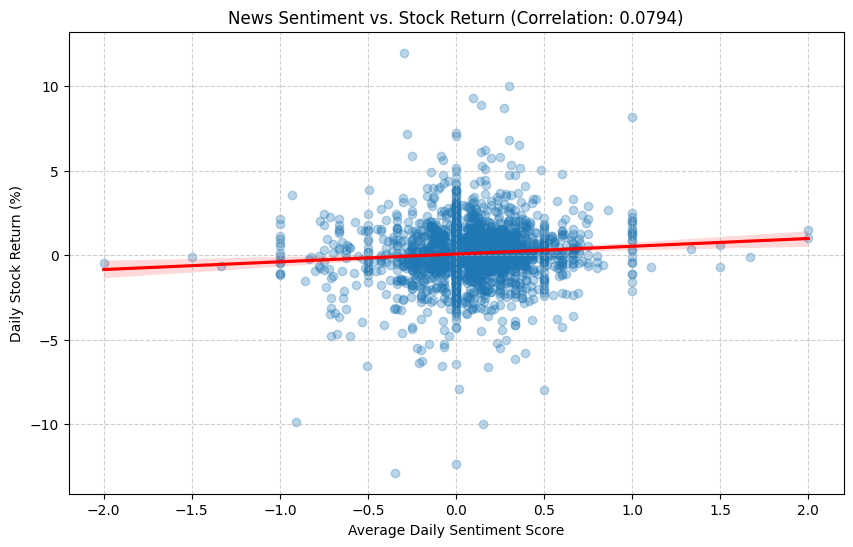


SUCCESS! Your correlation coefficient is: 0.0794
If the number is positive, good news usually means the stock goes up!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta


try:
    df_news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
    df_stock = pd.read_csv("../data/raw/yfinance_data/AAPL.csv") # Testing with AAPL
except:
    df_news = pd.read_csv("data/raw/raw_analyst_ratings.csv")
    df_stock = pd.read_csv("data/raw/AAPL.csv")


print("Analyzing Sentiment...")
try:
    from textblob import TextBlob
    df_news['sentiment'] = df_news['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
except ImportError:
    # Fallback if TextBlob isn't installed: Simple keyword score
    pos_words = ['up', 'high', 'buy', 'growth', 'beat', 'positive', 'surge']
    neg_words = ['down', 'low', 'sell', 'drop', 'miss', 'negative', 'fall']
    def quick_score(text):
        text = str(text).lower()
        score = 0
        for w in pos_words: score += 1 if w in text else 0
        for w in neg_words: score -= 1 if w in text else 0
        return score
    df_news['sentiment'] = df_news['headline'].apply(quick_score)


df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce', utc=True).dt.date
df_stock['Date'] = pd.to_datetime(df_stock['Date']).dt.date


def align_to_trading_day(date_obj):
    if date_obj.weekday() == 5: return date_obj + timedelta(days=2) # Sat -> Mon
    if date_obj.weekday() == 6: return date_obj + timedelta(days=1) # Sun -> Mon
    return date_obj

df_news['date'] = df_news['date'].apply(align_to_trading_day)



daily_sentiment = df_news.groupby('date')['sentiment'].mean().reset_index()


df_stock['daily_return'] = df_stock['Close'].pct_change() * 100


merged = pd.merge(daily_sentiment, df_stock, left_on='date', right_on='Date')
correlation = merged['sentiment'].corr(merged['daily_return'])

plt.figure(figsize=(10, 6))
sns.regplot(data=merged, x='sentiment', y='daily_return', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'News Sentiment vs. Stock Return (Correlation: {correlation:.4f})')
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Stock Return (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\nSUCCESS! Your correlation coefficient is: {correlation:.4f}")
print("If the number is positive, good news usually means the stock goes up!")